In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [2]:
data = {
    'App_ID':['C1','C2','C3','C4','C5'],
    'Credit_Score':[710,580,640,520,790],
    'Income_k':[65,35,45,28,110],
    'Emp_Status':['Employed','Unemployed','Employed','Unemployed','Employed'],
    'Default':['No','Yes','No','Yes','No']
}

df = pd.DataFrame(data)
print(df)

  App_ID  Credit_Score  Income_k  Emp_Status Default
0     C1           710        65    Employed      No
1     C2           580        35  Unemployed     Yes
2     C3           640        45    Employed      No
3     C4           520        28  Unemployed     Yes
4     C5           790       110    Employed      No


In [3]:
le = LabelEncoder()

df['Emp_Status'] = le.fit_transform(df['Emp_Status'])
df['Default'] = le.fit_transform(df['Default'])

print(df)

  App_ID  Credit_Score  Income_k  Emp_Status  Default
0     C1           710        65           0        0
1     C2           580        35           1        1
2     C3           640        45           0        0
3     C4           520        28           1        1
4     C5           790       110           0        0


In [4]:
X = df[['Credit_Score','Income_k','Emp_Status']]
y = df['Default']

model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

In [5]:
sample = [[600,40,1]]

prediction = model.predict(sample)
print(prediction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [6]:
prob = model.predict_proba(sample)

print(prob)

[[0.13335096 0.86664904]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


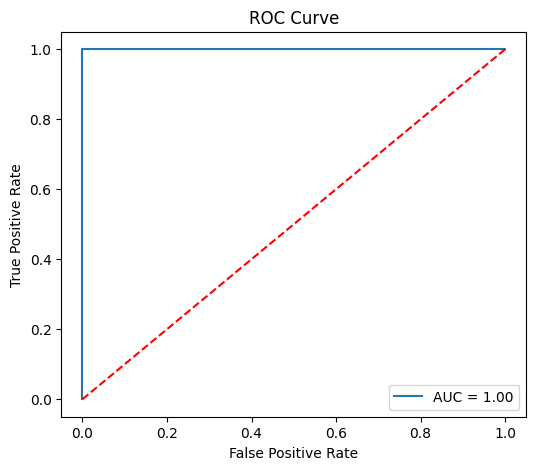

In [7]:
y_prob = model.predict_proba(X)[:,1]

fpr, tpr, threshold = roc_curve(y, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.show()